<a href="https://colab.research.google.com/github/raulsampaio2007-lab/machine_learning_SERS_1CC/blob/main/Aula_ML_Energia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Exercício
treinar um modelo preditivo de classificação de uma rede elétrica


fonte:

##Preparação do ambiente

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Machine learning
#Algoritmos do sklearn para classificação
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

#Separação os dados de treino e teste
from sklearn.model_selection import train_test_split
#X_train,X_test,y_train,y_test

#métricas para classificação
from sklearn.metrics import accuracy_score      #acuracia
from sklearn.metrics import confusion_matrix    # identificação de onde o modelo errou
from sklearn.metrics import classification_report #resumo de metricas



##Carregar os dados e gerar um dataframe


In [3]:
dados = pd.read_csv('https://raw.githubusercontent.com/raulsampaio2007-lab/machine_learning_SERS_1CC/refs/heads/main/Data_for_UCI_named.csv')

In [4]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


##Analise exploratória

In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


In [9]:
#Somente estatisticas de atributos numéricos

dados.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [8]:
#Somente estatistica de conteudo categorico

dados.describe(include='object')


,stabf
count,10000
unique,2
top,unstable
freq,6380


In [7]:
#checando a quantidade de clsses da coluna alvo(stabf)
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [10]:
#checando a quantidade de valores em cada classe da coluna alvo(stabf)
dados ['stabf'].value_counts()



,count
stabf,
unstable,6380
stable,3620


##Separação de dados de entrada:
Entrada(features)---->x

Sáida ()target----->y

In [11]:
#Features
x = dados.drop(['stab','stabf'],axis= 1)
x.head

<bound method NDFrame.head of           tau1      tau2      tau3      tau4        p1        p2        p3  \
0     2.959060  3.079885  8.381025  9.780754  3.763085 -0.782604 -1.257395   
1     9.304097  4.902524  3.047541  1.369357  5.067812 -1.940058 -1.872742   
2     8.971707  8.848428  3.046479  1.214518  3.405158 -1.207456 -1.277210   
3     0.716415  7.669600  4.486641  2.340563  3.963791 -1.027473 -1.938944   
4     3.134112  7.608772  4.943759  9.857573  3.525811 -1.125531 -1.845975   
...        ...       ...       ...       ...       ...       ...       ...   
9995  2.930406  9.487627  2.376523  6.187797  3.343416 -0.658054 -1.449106   
9996  3.392299  1.274827  2.954947  6.894759  4.349512 -1.663661 -0.952437   
9997  2.364034  2.842030  8.776391  1.008906  4.299976 -1.380719 -0.943884   
9998  9.631511  3.994398  2.757071  7.821347  2.514755 -0.966330 -0.649915   
9999  6.530527  6.781790  4.349695  8.673138  3.492807 -1.390285 -1.532193   

            p4        g1        g2        g3        g4  
0    -1.723086  0.650456  0.859578  0.887445  0.958034  
1    -1.255012  0.413441  0.862414  0.562139  0.781760  
2    -0.920492  0.163041  0.766689  0.839444  0.109853  
3    -0.997374  0.446209  0.976744  0.929381  0.362718  
4    -0.554305  0.797110  0.455450  0.656947  0.820923  
...        ...       ...       ...       ...       ...  
9995 -1.236256  0.601709  0.779642  0.813512  0.608385  
9996 -1.733414  0.502079  0.567242  0.285880  0.366120  
9997 -1.975373  0.487838  0.986505  0.149286  0.145984  
9998 -0.898510  0.365246  0.587558  0.889118  0.818391  
9999 -0.570329  0.073056  0.505441  0.378761  0.942631  

[10000 rows x 12 columns]>

In [12]:
#Variável alvo
y = dados['stabf']
y.head()

,stabf
0,unstable
1,stable
2,unstable
3,unstable
4,unstable


In [13]:
#Renomeando as classes da coluna alvo stabf(y)
y = y.map({'stable':'estável','unstable':'instável'})
y.head()

,stabf
0,instável
1,estável
2,instável
3,instável
4,instável


##Separação de dados treino e teste

In [18]:
# X_train, X_test,y_train,y_test
#Amostra aleatório para treino e teste
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=17)

#Amostra estratificada (balanceamento de classe)
#X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify = y, random_state=17)

In [20]:
X_test.shape

(2000, 12)

In [21]:
X_train.shape

(8000, 12)

In [22]:
y_test.shape

(2000,)

In [23]:
y_train.shape

(8000,)

In [24]:
y_train.value_counts()

,count
stabf,
instável,5105
estável,2895


## Treinamento e geração das previsões do modelo

In [25]:
#Instituindo o modelo
modelo_LR = LogisticRegression()


In [29]:
#gerando as previsões
y_predict = modelo_LR.predict(X_test)
y_predict

array(['instável', 'instável', 'instável', ..., 'estável', 'instável',
       'instável'], dtype=object)

##Avaliação do modelo

In [30]:
#Acurácia
acuracia =accuracy_score(y_test,y_predict)

print(f'Acurácia do modelo: {acuracia*100:.2f}%')
#

Acurácia do modelo: 82.45%


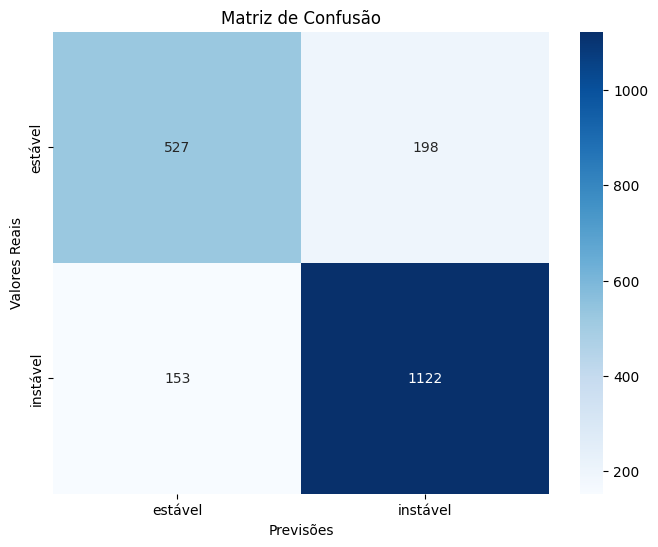

In [32]:
# Matriz de confusão usando o seaborn e matplotlib
matriz_confusao = confusion_matrix(y_test,y_predict)

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues',
            xticklabels=modelo_LR.classes_, yticklabels=modelo_LR.classes_)
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.title('Matriz de Confusão')
plt.show()

In [33]:
#classification Report usando seaborn e matplotlib
report = classification_report(y_test,y_predict)
print(report)


              precision    recall  f1-score   support

     estável       0.78      0.73      0.75       725
    instável       0.85      0.88      0.86      1275

    accuracy                           0.82      2000
   macro avg       0.81      0.80      0.81      2000
weighted avg       0.82      0.82      0.82      2000

